In [1]:
!pip install yfinance pandas numpy matplotlib seaborn scipy

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

from scipy.stats import norm

plt.style.use("seaborn-v0_8-whitegrid")


In [3]:
tickers = ["AAPL", "MSFT", "JPM", "XOM", "JNJ"]

start_date = "2021-01-01"
end_date = "2026-01-01"

data = yf.download(
    tickers,
    start=start_date,
    end=end_date,
    auto_adjust=True
)

data.head()


[*********************100%***********************]  5 of 5 completed


Price            Close                                                 \
Ticker            AAPL         JNJ         JPM        MSFT        XOM   
Date                                                                    
2021-01-04  125.632507  133.628326  109.000534  207.565399  33.251328   
2021-01-05  127.185806  135.199402  109.593651  207.765594  34.853802   
2021-01-06  122.904503  136.471649  114.739693  202.378403  35.743183   
2021-01-07  127.098427  136.932755  118.507652  208.137436  36.023617   
2021-01-08  128.195450  136.650940  118.638489  209.405655  36.424225   

Price             High                                                 ...  \
Ticker            AAPL         JNJ         JPM        MSFT        XOM  ...   
Date                                                                   ...   
2021-01-04  129.709906  134.379723  110.723827  212.628433  33.852255  ...   
2021-01-05  127.894508  135.558019  110.160591  208.356769  35.895409  ...   
2021-01-06  127.224610  136.813186  115.803794  206.421209  36.135788  ...   
2021-01-07  127.787708  137.496302  120.531194  209.138604  36.512372  ...   
2021-01-08  128.758521  137.556037  118.926321  210.321013  36.712671  ...   

Price             Open                                                 \
Ticker            AAPL         JNJ         JPM        MSFT        XOM   
Date                                                                    
2021-01-04  129.622536  134.260184  110.412074  212.180291  33.211266   
2021-01-05  125.127694  133.414848  109.017987  207.155361  33.523749   
2021-01-06  123.991812  134.260168  113.283098  202.302122  35.582935   
2021-01-07  124.613156  135.762977  118.350660  204.085101  36.055667   
2021-01-08  128.564348  137.052253  118.594875  208.509371  36.215905   

Price          Volume                                          
Ticker           AAPL       JNJ       JPM      MSFT       XOM  
Date                                                           
2021-01-04  143301900  11765900  16819900  37130100  27764700  
2021-01-05   97664900   9602300  13731200  23823000  44035100  
2021-01-06  155088000   8230100  24909100  35930700  36484800  
2021-01-07  109578200   7747200  21940400  27694500  29528100  
2021-01-08  105158200   8228900  12035100  22956200  28628200  

[5 rows x 25 columns]

In [4]:
prices = data["Close"].copy()

prices.head()


Ticker,AAPL,JNJ,JPM,MSFT,XOM
Date,,,,,
2021-01-04,125.632507,133.628326,109.000534,207.565399,33.251328
2021-01-05,127.185806,135.199402,109.593651,207.765594,34.853802
2021-01-06,122.904503,136.471649,114.739693,202.378403,35.743183
2021-01-07,127.098427,136.932755,118.507652,208.137436,36.023617
2021-01-08,128.195450,136.650940,118.638489,209.405655,36.424225


In [5]:
prices.info()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1255 entries, 2021-01-04 to 2025-12-31
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    1255 non-null   float64
 1   JNJ     1255 non-null   float64
 2   JPM     1255 non-null   float64
 3   MSFT    1255 non-null   float64
 4   XOM     1255 non-null   float64
dtypes: float64(5)
memory usage: 58.8 KB


In [6]:
prices.isna().sum()


,0
Ticker,
AAPL,0
JNJ,0
JPM,0
MSFT,0
XOM,0


In [7]:
returns = prices.pct_change().dropna()

returns.head()


Ticker,AAPL,JNJ,JPM,MSFT,XOM
Date,,,,,
2021-01-05,0.012364,0.011757,0.005441,0.000964,0.048193
2021-01-06,-0.033662,0.009410,0.046956,-0.025929,0.025517
2021-01-07,0.034123,0.003379,0.032839,0.028457,0.007846
2021-01-08,0.008631,-0.002058,0.001104,0.006093,0.011121
2021-01-11,-0.023249,-0.004186,0.014924,-0.009699,0.030357


In [8]:
weights = pd.Series(
    {
        "AAPL": 0.20,
        "MSFT": 0.20,
        "JPM": 0.20,
        "XOM": 0.20,
        "JNJ": 0.20
    }
)

weights


,0
AAPL,0.2
MSFT,0.2
JPM,0.2
XOM,0.2
JNJ,0.2


In [9]:
weights.sum()


np.float64(1.0)

In [10]:
portfolio_returns = returns.dot(weights)

portfolio_returns.head()


,0
Date,
2021-01-05,0.015744
2021-01-06,0.004458
2021-01-07,0.021329
2021-01-08,0.004978
2021-01-11,0.001629


In [11]:
cumulative_returns = (1 + portfolio_returns).cumprod()

cumulative_returns.head()


,0
Date,
2021-01-05,1.015744
2021-01-06,1.020273
2021-01-07,1.042034
2021-01-08,1.047221
2021-01-11,1.048928


In [12]:
annualized_return = (
    (1 + portfolio_returns.mean()) ** 252
) - 1

annualized_return


np.float64(0.2284645622424044)

In [13]:
annualized_volatility = portfolio_returns.std() * np.sqrt(252)

print(
    f"Annualized Volatility: "
    f"{annualized_volatility:.2%}"
)


Annualized Volatility: 15.72%


In [14]:
risk_free_rate = 0.04


In [15]:
sharpe_ratio = (
    annualized_return - risk_free_rate
) / annualized_volatility

print(f"Sharpe Ratio: {sharpe_ratio:.2f}")


Sharpe Ratio: 1.20


In [16]:
running_max = cumulative_returns.cummax()

drawdown = (
    cumulative_returns / running_max
) - 1


In [17]:
max_drawdown = drawdown.min()

print(f"Maximum Drawdown: {max_drawdown:.2%}")


Maximum Drawdown: -16.01%


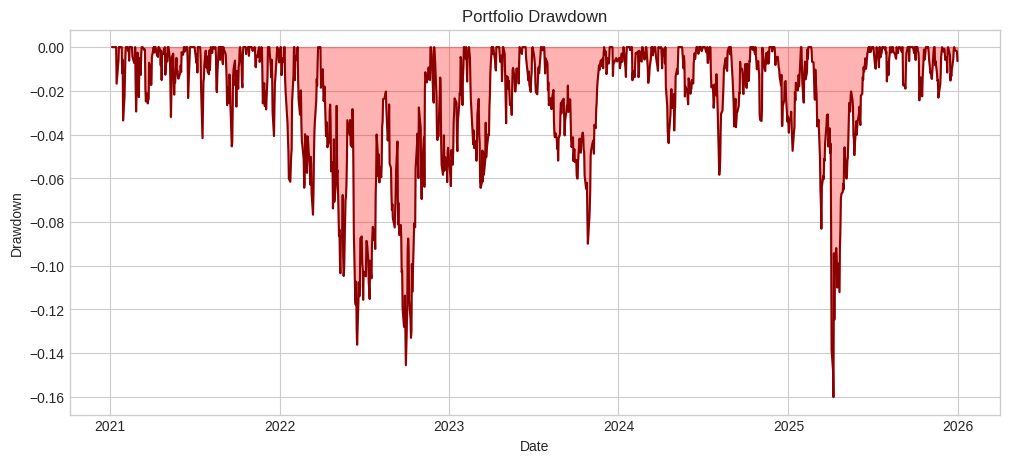

In [18]:
plt.figure(figsize=(12, 5))

plt.fill_between(
    drawdown.index,
    drawdown.values,
    0,
    color="red",
    alpha=0.3
)

plt.plot(
    drawdown,
    color="darkred"
)

plt.title("Portfolio Drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown")

plt.show()


In [19]:
correlation_matrix = returns.corr()

correlation_matrix


Ticker,AAPL,JNJ,JPM,MSFT,XOM
Ticker,,,,,
AAPL,1.000000,0.154075,0.345422,0.633958,0.189420
JNJ,0.154075,1.000000,0.208335,0.075168,0.132778
JPM,0.345422,0.208335,1.000000,0.311269,0.363756
MSFT,0.633958,0.075168,0.311269,1.000000,0.084765
XOM,0.189420,0.132778,0.363756,0.084765,1.000000


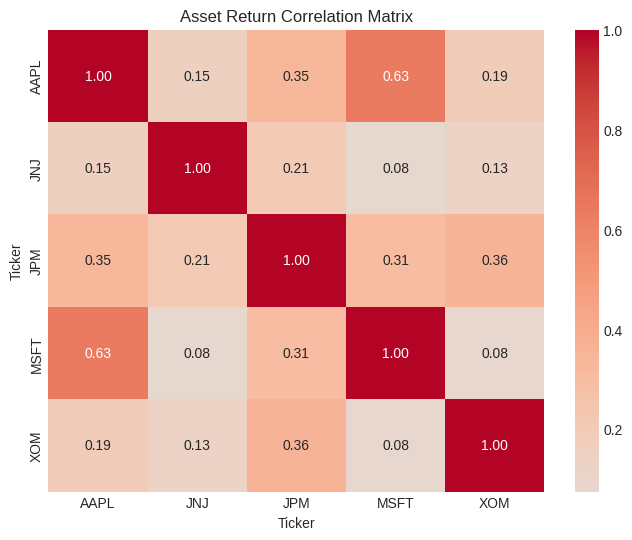

In [20]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title("Asset Return Correlation Matrix")

plt.show()


In [21]:
covariance_matrix = returns.cov() * 252

covariance_matrix


Ticker,AAPL,JNJ,JPM,MSFT,XOM
Ticker,,,,,
AAPL,0.077633,0.007181,0.023363,0.045421,0.014262
JNJ,0.007181,0.027984,0.008460,0.003233,0.006002
JPM,0.023363,0.008460,0.058926,0.019430,0.023862
MSFT,0.045421,0.003233,0.019430,0.066123,0.005890
XOM,0.014262,0.006002,0.023862,0.005890,0.073027


In [22]:
portfolio_variance = (
    weights.values.T
    @ covariance_matrix.values
    @ weights.values
)

portfolio_volatility = np.sqrt(portfolio_variance)

print(
    f"Portfolio Volatility: "
    f"{portfolio_volatility:.2%}"
)


Portfolio Volatility: 15.72%


In [23]:
confidence_level = 0.95


In [24]:
var_95 = portfolio_returns.quantile(
    1 - confidence_level
)

print(f"95% Historical VaR: {var_95:.2%}")


95% Historical VaR: -1.52%


In [25]:
mean_return = portfolio_returns.mean()
std_return = portfolio_returns.std()

z_score = norm.ppf(1 - confidence_level)

parametric_var = (
    mean_return + z_score * std_return
)

print(
    f"95% Parametric VaR: "
    f"{parametric_var:.2%}"
)


95% Parametric VaR: -1.55%


In [26]:
expected_shortfall = portfolio_returns[
    portfolio_returns <= var_95
].mean()

print(
    f"95% Expected Shortfall: "
    f"{expected_shortfall:.2%}"
)


95% Expected Shortfall: -2.20%


In [27]:
cov_matrix = returns.cov() * 252


In [28]:
portfolio_variance = (
    weights.values.T
    @ cov_matrix.values
    @ weights.values
)


In [29]:
marginal_contribution = (
    cov_matrix.values @ weights.values
)


In [30]:
risk_contribution = (
    weights.values * marginal_contribution
) / portfolio_variance


In [31]:
risk_contribution_df = pd.DataFrame(
    {
        "Ticker": weights.index,
        "Weight": weights.values,
        "Risk Contribution": risk_contribution
    }
)

risk_contribution_df


,Ticker,Weight,Risk Contribution
0,AAPL,0.2,0.271661
1,MSFT,0.2,0.085550
2,JPM,0.2,0.216928
3,XOM,0.2,0.226730
4,JNJ,0.2,0.199131


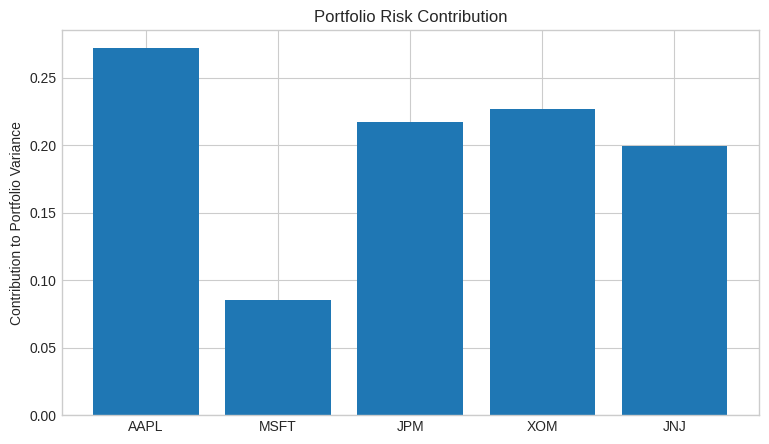

In [32]:
plt.figure(figsize=(9, 5))

plt.bar(
    risk_contribution_df["Ticker"],
    risk_contribution_df["Risk Contribution"]
)

plt.title("Portfolio Risk Contribution")
plt.ylabel("Contribution to Portfolio Variance")

plt.show()


In [33]:
stress_scenarios = {
    "Market Crash": -0.20,
    "Moderate Decline": -0.10,
    "Mild Correction": -0.05,
    "Normal": 0.00
}


In [34]:
stress_results = {}

for scenario, market_shock in stress_scenarios.items():
    portfolio_loss = market_shock
    stress_results[scenario] = portfolio_loss

stress_results


{'Market Crash': -0.2,
 'Moderate Decline': -0.1,
 'Mild Correction': -0.05,
 'Normal': 0.0}

In [35]:
scenarios = {
    "Base Case": {
        "AAPL": 0.00,
        "MSFT": 0.00,
        "JPM": 0.00,
        "XOM": 0.00,
        "JNJ": 0.00
    },
    "Market Correction": {
        "AAPL": -0.10,
        "MSFT": -0.10,
        "JPM": -0.10,
        "XOM": -0.10,
        "JNJ": -0.10
    },
    "Severe Market Crash": {
        "AAPL": -0.30,
        "MSFT": -0.30,
        "JPM": -0.35,
        "XOM": -0.25,
        "JNJ": -0.15
    }
}


In [36]:
stress_results = {}

for scenario, shocks in scenarios.items():

    portfolio_return = sum(
        weights[ticker] * shocks[ticker]
        for ticker in weights.index
    )

    stress_results[scenario] = portfolio_return

stress_results


{'Base Case': np.float64(0.0),
 'Market Correction': np.float64(-0.10000000000000002),
 'Severe Market Crash': np.float64(-0.27)}

In [37]:
stress_df = pd.DataFrame(
    stress_results.items(),
    columns=["Scenario", "Portfolio Return"]
)

stress_df


,Scenario,Portfolio Return
0,Base Case,0.00
1,Market Correction,-0.10
2,Severe Market Crash,-0.27


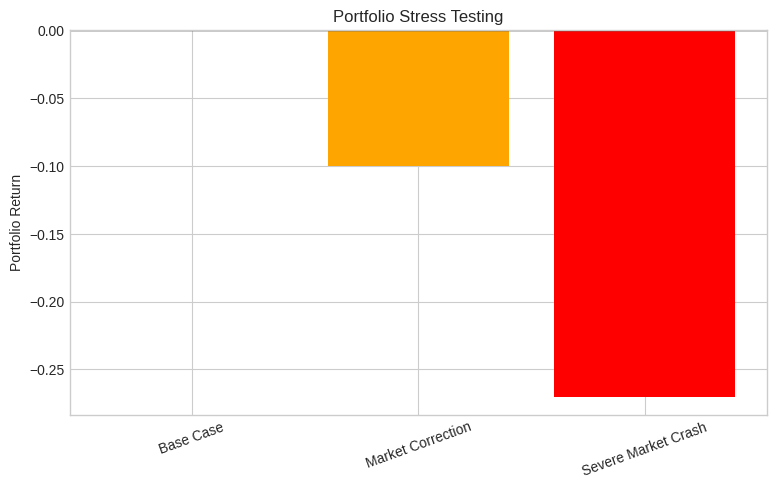

In [38]:
plt.figure(figsize=(9, 5))

plt.bar(
    stress_df["Scenario"],
    stress_df["Portfolio Return"],
    color=["green", "orange", "red"]
)

plt.axhline(0, color="black", linewidth=1)

plt.title("Portfolio Stress Testing")
plt.ylabel("Portfolio Return")

plt.xticks(rotation=20)

plt.show()


In [40]:
# Calculate CAGR

total_days = (
    portfolio_returns.index[-1]
    - portfolio_returns.index[0]
).days

cumulative_returns = (1 + portfolio_returns).cumprod()

cagr = (
    cumulative_returns.iloc[-1]
    ** (365 / total_days)
) - 1

print(f"CAGR: {cagr:.2%}")


CAGR: 21.28%


In [41]:
risk_report = pd.DataFrame({
    "Metric": [
        "CAGR",
        "Annualized Volatility",
        "Sharpe Ratio",
        "Maximum Drawdown",
        "95% Historical VaR",
        "95% Expected Shortfall"
    ],
    "Value": [
        cagr,
        annualized_volatility,
        sharpe_ratio,
        max_drawdown,
        var_95,
        expected_shortfall
    ]
})

risk_report


,Metric,Value
0,CAGR,0.212812
1,Annualized Volatility,0.157214
2,Sharpe Ratio,1.198781
3,Maximum Drawdown,-0.160096
4,95% Historical VaR,-0.015156
5,95% Expected Shortfall,-0.022027
